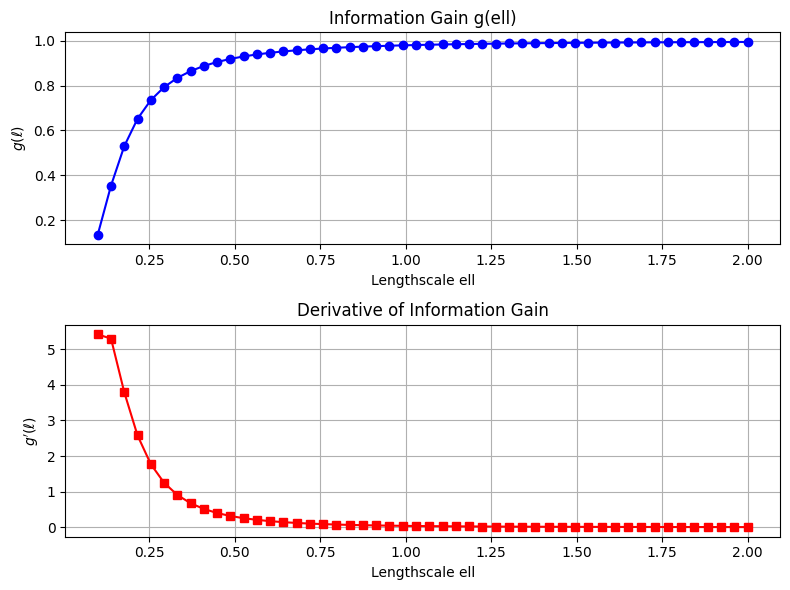

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def pairwise_sq_dists(X, Y=None):
    """
    Compute pairwise squared Euclidean distances between rows of X and Y.
    If Y is None, computes pairwise distances among rows of X.
    """
    if Y is None:
        Y = X
    X_norm = np.sum(X**2, axis=1).reshape(-1, 1)
    Y_norm = np.sum(Y**2, axis=1).reshape(1, -1)
    return X_norm + Y_norm - 2 * np.dot(X, Y.T)

def compute_g_gprime(X, ell, sigma_f, sigma_n):
    """
    Given:
      - X: an (n x d) numpy array of training points,
      - ell: lengthscale (a positive scalar),
      - sigma_f: signal amplitude (so that k(.,.) uses sigma_f^2),
      - sigma_n: noise standard deviation.
      
    Computes:
      - g(ell) = k(0,X) [K(X,X) + sigma_n^2 I]^{-1} k(X,0),
      - g'(ell) = derivative of g with respect to ell.
    
    Here, the kernel is defined as
      k_ell(x,x') = sigma_f^2 * exp( -||x-x'||^2/(2*ell^2) ).
      
    The derivative is computed using the fact that
      ∂ₗ k_ell(x,x') = k_ell(x,x') * (||x-x'||^2)/(ell^3).
    """
    n = X.shape[0]
    
    # Compute F: vector of k(0, x_i)
    # Note: ||0 - x_i||^2 = ||x_i||^2.
    normX_sq = np.sum(X**2, axis=1)      # shape (n,)
    F = (sigma_f**2) * np.exp(-normX_sq / (2 * ell**2))  # shape (n,)
    
    # Compute the n x n kernel matrix K for the training data:
    D = pairwise_sq_dists(X)  # shape (n, n)
    K = (sigma_f**2) * np.exp(-D / (2 * ell**2))
    
    # A = K + sigma_n^2 I
    A = K + (sigma_n**2) * np.eye(n)
    
    # Solve for v = A^{-1} F.
    v = np.linalg.solve(A, F)  # shape (n,)
    
    # Compute g(ell) = F^T * v.
    g = np.dot(F, v)
    
    # Compute derivative of F with respect to ell.
    # For each training point: 
    # F_i = sigma_f^2 * exp(-||x_i||^2/(2*ell^2)).
    # So, F'_i = F_i * (||x_i||^2)/(ell^3).
    Fprime = F * (normX_sq / ell**3)
    
    # Compute derivative of the training kernel matrix K:
    # For each i,j, k(x_i,x_j) = sigma_f^2 exp(-||x_i-x_j||^2/(2*ell^2)).
    # So, d/dell k(x_i,x_j) = k(x_i,x_j) * (||x_i-x_j||^2)/(ell^3).
    Aprime = K * (D / ell**3)  # elementwise multiplication; shape (n,n)
    
    # The derivative of g is given by:
    # g'(ell) = 2 * Fprime^T * A^{-1} * F  -  F^T * A^{-1} * Aprime * A^{-1} * F.
    # But note: A^{-1} F = v.
    term1 = 2 * np.dot(Fprime, v)
    term2 = np.dot(v, np.dot(Aprime, v))
    gprime = term1 - term2
    
    return g, gprime

if __name__ == '__main__':
    # Example: 10 training points in 2D, randomly generated.
    np.random.seed(0)
    # X = np.random.randn(10, 2)
    X = np.array([[0.1, 0.1], [100,100]])
    sigma_f = 1.0
    sigma_n = 0.0
    
    # Compute g and g' for a range of lengthscales.
    ell_values = np.linspace(0.1, 2.0, 50)
    g_values = []
    gprime_values = []
    
    for ell in ell_values:
        g_val, gprime_val = compute_g_gprime(X, ell, sigma_f, sigma_n)
        g_values.append(g_val)
        gprime_values.append(gprime_val)
    
    # Plot g and g'
    plt.figure(figsize=(8, 6))
    
    plt.subplot(2,1,1)
    plt.plot(ell_values, g_values, 'b-', marker='o')
    plt.xlabel('Lengthscale ell')
    plt.ylabel('$g(\ell)$')
    plt.title('Information Gain g(ell)')
    plt.grid(True)
    
    plt.subplot(2,1,2)
    plt.plot(ell_values, gprime_values, 'r-', marker='s')
    plt.xlabel('Lengthscale ell')
    plt.ylabel("$g'(\ell)$")
    plt.title('Derivative of Information Gain')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


In [ ]:
X = np.array([[0.1, 0.1], [100,100]])

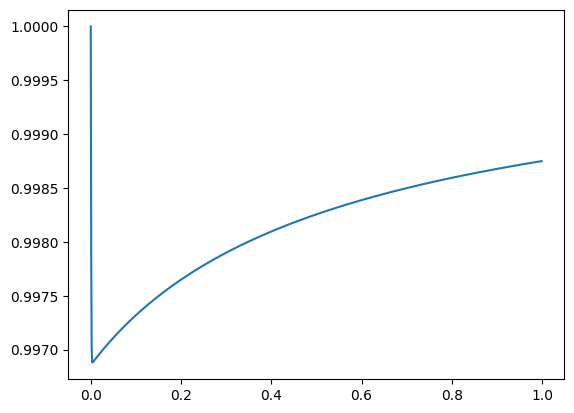

In [105]:
N = 1000
ells = [i/1000 for i in range(N)]
omega = np.linspace(0, 1000, 50000)

ints = []

lambd = 1

for i in range(N):
    ints.append((1/(spectral(omega, ells[i]) + lambd)).mean())


plt.plot(ells, ints)


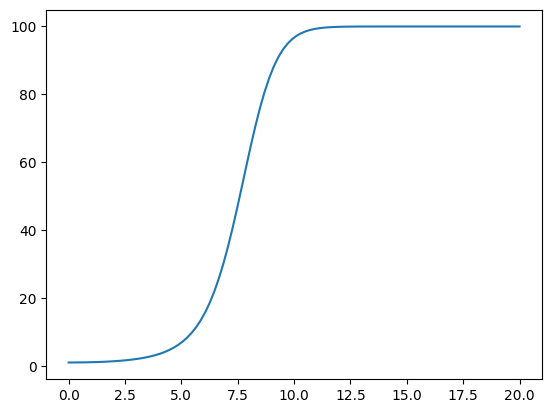

In [83]:
import math

def spectral(omega, ell, d=1):
    output = (2 * math.pi * (ell ** 2)) ** (d/2) * np.exp(- (ell ** 2) * omega ** 2 / 2)
    return output

omega = np.linspace(0, 20, 100)
d = 2

ell1 = 0.2
spec_ell1 = spectral(omega, ell1, d=d)

ell2 = 0.4
spec_ell2 = spectral(omega, ell2, d=d)

lambd = 0.01

plt.plot(omega, 1/(spec_ell2+lambd))

In [40]:
omega = np.linspace(0, 20000000, 10000000)

ell1 = 0.2
spec_ell1 = spectral(omega, ell1, d=10)

ell2 = 0.201
spec_ell2 = spectral(omega, ell2, d=10)

np.mean(spec_ell2 - spec_ell1)

1.6988949677965474e-11

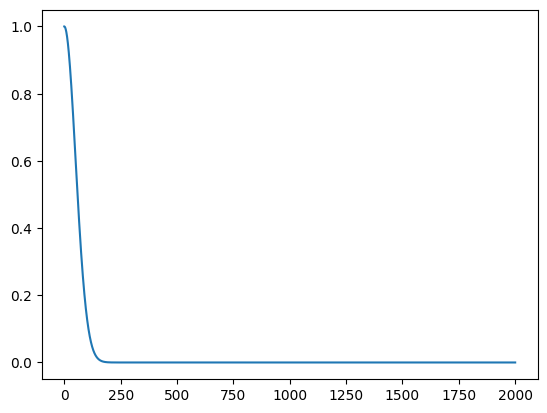

In [41]:
epsilon = 0.01
omega = np.linspace(0, 2000, 10000)

plt.plot(omega, norm_fourier(omega, epsilon))

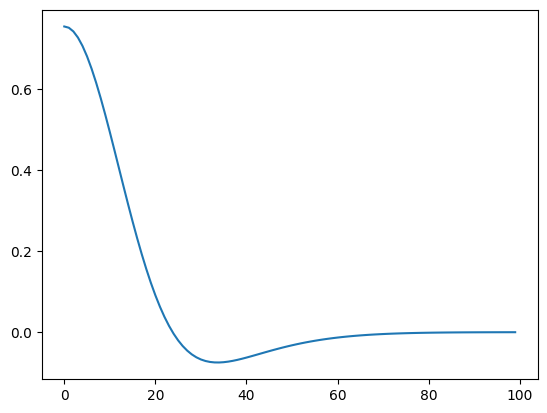

In [16]:
def norm_fourier(omega, epsilon):
    output = np.exp( - 2 * epsilon ** 2 * omega ** 2)
    return output

epsilon = 0.0001
fourier_omega = norm_fourier(omega, epsilon)

plt.plot((spec_ell2 - spec_ell1) * fourier_omega)

In [14]:
(spec_ell2 - spec_ell1) * fourier_omega

array([ 7.53982237e-001,  2.14135530e-004,  4.90528897e-015,
        9.06290527e-033,  1.35039506e-057,  1.62252593e-089,
        1.57176509e-128,  1.22730970e-174,  7.72270582e-228,
        3.91451852e-288,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
        0.00000000e+000,  0.00000000e+000,  0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000, -0.00000000e+000, -0.00000000e+000,
       -0.00000000e+000,

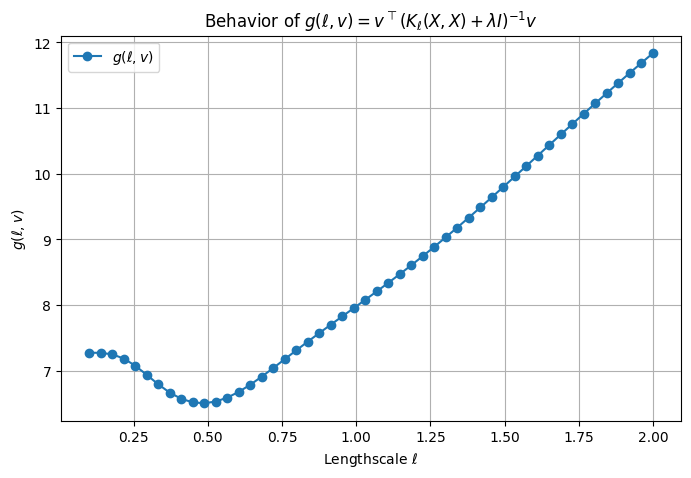

In [77]:
import numpy as np
import matplotlib.pyplot as plt

def squared_exponential_kernel(X, ell, sigma_f=1.0):
    """
    Computes the squared-exponential kernel matrix K for a set of points X.
    
    Parameters:
        X : numpy.ndarray
            An (n x d) array of n points in d dimensions.
        ell : float
            The lengthscale parameter.
        sigma_f : float, optional
            The signal variance (default is 1.0).
    
    Returns:
        K : numpy.ndarray
            An (n x n) kernel matrix with entries
            K[i,j] = sigma_f^2 * exp( -||x_i - x_j||^2 / (2*ell^2) ).
    """
    # Compute the squared Euclidean distances using broadcasting.
    sq_norms = np.sum(X**2, axis=1).reshape(-1, 1)
    dists_sq = sq_norms + sq_norms.T - 2 * np.dot(X, X.T)
    K = sigma_f**2 * np.exp(-dists_sq / (2 * ell**2))
    return K

def g_value(ell, X, v, lam, sigma_f=1.0):
    """
    Computes g(ell, v) = v^T (K_ell(X,X) + lambda I)^{-1} v.
    
    Parameters:
        ell : float
            The lengthscale parameter.
        X : numpy.ndarray
            An (n x d) array of data points.
        v : numpy.ndarray
            A vector of length n.
        lam : float
            The noise parameter (lambda).
        sigma_f : float, optional
            The signal variance (default is 1.0).
    
    Returns:
        g : float
            The scalar value v^T (K_ell(X,X) + lambda I)^{-1} v.
    """
    K = squared_exponential_kernel(X, ell, sigma_f)
    if v is None:
        v = np.exp(-(X ** 2).sum(axis=1)/ (2 * ell ** 2))
        print(v)
    n = X.shape[0]
    A = K + lam * np.eye(n)
    # Solve the linear system instead of computing the inverse explicitly.
    A_inv_v = np.linalg.solve(A, v)
    g = np.dot(v, A_inv_v)
    return g

# Example usage:
if __name__ == '__main__':
    np.random.seed(2)
    n = 10  # number of data points
    d = 2   # dimensionality
    # Generate random data points in R^d
    X = np.random.randn(n, d)
    
    # Choose a fixed vector v (for example, random)
    v = np.array([0,1,1,1,1,1,1,1,0,1]) #np.random.randn(n)
    
    # Set the noise parameter lambda and signal variance
    lam = 0.1
    sigma_f = 1.0
    
    # Evaluate g(ell, v) for a range of ell values
    ell_values = np.linspace(0.1, 2.0, 50)
    g_values = [g_value(ell, X, v, lam, sigma_f) for ell in ell_values]
    
    plt.figure(figsize=(8, 5))
    plt.plot(ell_values, g_values, 'o-', label=r'$g(\ell,v)$')
    plt.xlabel(r'Lengthscale $\ell$')
    plt.ylabel(r'$g(\ell,v)$')
    plt.title(r'Behavior of $g(\ell,v) = v^\top \left(K_\ell(X,X) + \lambda I\right)^{-1} v$')
    plt.legend()
    plt.grid(True)
    plt.show()


In [58]:
X

array([[-0.41675785, -0.05626683],
       [-2.1361961 ,  1.64027081],
       [-1.79343559, -0.84174737],
       [ 0.50288142, -1.24528809],
       [-1.05795222, -0.90900761]])

In [62]:
squared_exponential_kernel(X, ell, sigma_f)

array([[1.        , 0.48222789, 0.73049882, 0.75394301, 0.86737217],
       [0.48222789, 1.        , 0.45623951, 0.14787358, 0.38378269],
       [0.73049882, 0.45623951, 1.        , 0.50687563, 0.93409002],
       [0.75394301, 0.14787358, 0.50687563, 1.        , 0.72712217],
       [0.86737217, 0.38378269, 0.93409002, 0.72712217, 1.        ]])

[1.44439047e-004 3.05671402e-158 5.89925874e-086 6.83322539e-040
 5.65913995e-043]
[1.01373911e-02 1.62508969e-82 5.55850187e-45 4.60766673e-21
 1.15671216e-22]
[6.05054541e-02 1.08135197e-50 9.20496801e-28 3.76840472e-13
 3.96771618e-14]
[1.51136767e-01 2.19263454e-34 6.13097839e-19 4.27389470e-09
 9.38131240e-10]
[2.56969617e-01 6.24675100e-25 8.00460339e-14 9.58720316e-07
 3.22194886e-07]
[3.59197952e-01 5.77471449e-19 1.35331457e-10 2.91797664e-05
 1.28302363e-05]
[4.49734865e-01 5.82951951e-15 1.98594391e-08 2.88858315e-04
 1.52117964e-04]
[5.26785660e-01 3.82394004e-12 6.63962577e-07 1.44907124e-03
 8.66361941e-04]
[5.91252574e-01 4.35533166e-10 8.60785210e-06 4.70362053e-03
 3.08516805e-03]
[6.44899132e-01 1.53495992e-08 5.91558388e-05 1.14052845e-02
 8.02088308e-03]
[6.89569119e-01 2.39382113e-07 2.61524078e-04 2.25807932e-02
 1.67570261e-02]
[7.26905102e-01 2.08140561e-06 8.42822077e-04 3.86619240e-02
 2.99308141e-02]
[7.58279028e-01 1.17775928e-05 2.15284167e-03 5.94893308e-0

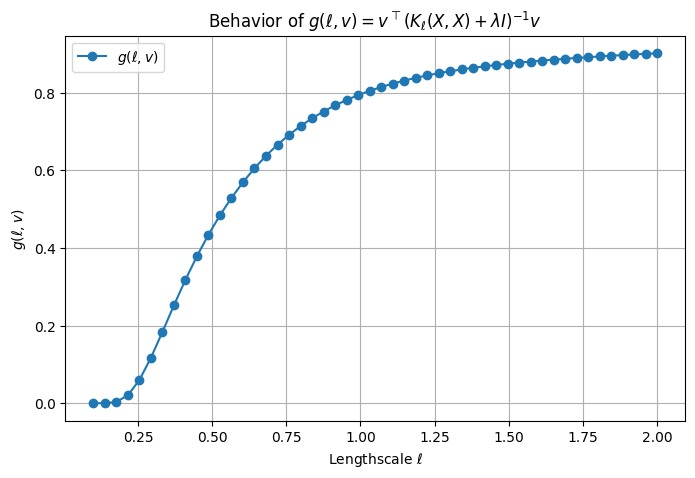

In [65]:
np.random.seed(2)
n = 5  # number of data points
d = 2   # dimensionality
# Generate random data points in R^d
X = np.random.randn(n, d)

# Choose a fixed vector v (for example, random


# Set the noise parameter lambda and signal variance
lam = 0.1
sigma_f = 1.0

# Evaluate g(ell, v) for a range of ell values
ell_values = np.linspace(0.1, 2.0, 50)
g_values = [g_value(ell, X, None, lam, sigma_f) for ell in ell_values]

plt.figure(figsize=(8, 5))
plt.plot(ell_values, g_values, 'o-', label=r'$g(\ell,v)$')
plt.xlabel(r'Lengthscale $\ell$')
plt.ylabel(r'$g(\ell,v)$')
plt.title(r'Behavior of $g(\ell,v) = v^\top \left(K_\ell(X,X) + \lambda I\right)^{-1} v$')
plt.legend()
plt.grid(True)
plt.show()


In [50]:
v

array([-0.87810789, -0.15643417,  0.25657045, -0.98877905, -0.33882197,
       -0.23618403, -0.63765501, -1.18761229, -1.42121723, -0.1534952 ])

## Investigation

In [106]:
import numpy as np
from numpy.linalg import solve

# Example data: X is an array of shape (n, d)
# e.g. random 2D points
# In practice you'll load/generate your real data
np.random.seed(0)
X = np.random.randn(5, 2)  # 5 points in R^2
n = len(X)

# We'll define "ell" (length-scale) and "lambda" (regularization/noise)
ell = 1.0
lam = 1e-6  # e.g. small Tikhonov regularization


In [832]:
from scipy.spatial.distance import cdist

def matern32_kernel(X, Y, ell=1.0):
    
    r = cdist(X / ell, Y / ell, metric='euclidean')
    sqrt3 = np.sqrt(3.0)
    K = (1.0 + sqrt3 * r) * np.exp(-sqrt3 * r)
    return K

def imq_kernel(X, Y, alpha=1.0, c=1.0, ell=1.0):

    D2 = cdist(X / ell, Y / ell, metric='sqeuclidean')
    K = 1.0 / ((D2 + c**2) ** alpha)
    return K

def gauss_kernel(X, Y, ell=1.0):
    r = cdist(X, Y, metric="sqeuclidean")
    K = np.exp( - r / (2 * ell ** 2) )
    return K

def compute_alpha(K, k0, lam=1e-6):
    n = K.shape[0]
    # Add a small multiple of the identity for regularization
    K_reg = K.copy()
    K_reg[np.diag_indices(n)] += lam
    # Solve the linear system (K + lam I) alpha = k0
    alpha = np.linalg.solve(K_reg, k0)
    return alpha


$$\frac{1}{\ell^3}\int_0^\infty s\left[ 2\sum_{i=1}^n \alpha_i\|x_i\|^2 \exp\left\{-\frac{s\|x_i\|^2}{2\ell^2}\right\} - \sum_{i,j} \alpha_i\alpha_j \|x_i-x_j\|^2 \exp\left\{-\frac{s\|x_i - x_j\|^2}{2\ell^2}\right\} \right]\,\mathrm{d}\mu(s).$$

In [610]:
def compute_integrand(s, X, ell=1., kernel=matern32_kernel, lambd = 0):
    # s of shape (m, 1)
    K = kernel(X,X, ell=ell)
    k0 = kernel(X, np.zeros([1,X.shape[1]]), ell=ell)

    alpha = np.linalg.solve(K + lambd * np.eye(X.shape[0]), k0)

    # Ensure s is a 1D array for vectorized operations.
    s_arr = np.atleast_1d(s)  # shape: (m,)
    n = X.shape[0]
    
    # Compute squared norms of X, shape: (n,)
    X_norms = np.sum(X**2, axis=1)
    
    # Term 1: 2 * sum_{i} alpha_i ||x_i||^2 exp(- s ||x_i||^2/(2 ell^2))
    # Compute outer product: for each s in s_arr and for each i, exp(- s * ||x_i||^2/(2 ell^2))
    exp_term1 = np.exp(- np.outer(s_arr, X_norms) / (2 * ell**2))  # shape (m, n)
    # Multiply by alpha_i * ||x_i||^2
    term1 = 2.0 * np.sum( (alpha.flatten() * X_norms)[np.newaxis, :] * exp_term1, axis=1)  # shape (m,)
    
    # Term 2: sum_{i,j} alpha_i alpha_j ||x_i-x_j||^2 exp(- s||x_i-x_j||^2/(2 ell^2))
    # Compute pairwise squared distances, shape (n, n)
    D2 = cdist(X, X, metric='sqeuclidean')
    # Compute exp(- s * D2/(2 ell^2)) for each s.
    # First, flatten D2 to shape (n*n,) then do outer product with s_arr:
    exp_term2 = np.exp(- np.outer(s_arr, D2.flatten()) / (2 * ell**2))  # shape (m, n*n)
    # Reshape to (m, n, n)
    exp_term2 = exp_term2.reshape(len(s_arr), n, n)
    # Compute outer product of alpha: shape (n, n)
    alpha_outer = np.outer(alpha.flatten(), alpha.flatten())
    # Multiply elementwise by D2 and exp_term2, then sum over i and j for each s.
    term2 = np.sum(alpha_outer[np.newaxis, :, :] * D2[np.newaxis, :, :] * exp_term2, axis=(1, 2))  # shape (m,)
    
    integrand_val = (s_arr * (term1 - term2)) / (ell**3)
    
    # If the input s was a scalar, return a scalar; otherwise, return the array.
    if integrand_val.size == 1:
        return integrand_val.item()
    else:
        return integrand_val


In [824]:
def compute_integrand2(s, X, ell=1.0, kernel=matern32_kernel, lambd=0):
    # Compute the kernel matrix K = k_ell(X,X)
    K = kernel(X, X, ell=ell)
    # Compute k0 = k_ell(0, X), where 0 is the zero vector.
    k0 = kernel(X, np.zeros((1, X.shape[1])), ell=ell)
    
    # Solve for alpha: (K + lambd I) alpha = k0.
    alpha = np.linalg.solve(K + lambd * np.eye(X.shape[0]), k0)  # shape (n, 1)
    
    # Ensure s is a 1D array.
    s_arr = np.atleast_1d(s)  # shape: (m,)
    n = X.shape[0]
    
    # Precompute ||x_i||^2 for each i, shape (n,)
    X_norms = np.sum(X**2, axis=1)
    
    # Term 1: 2 * sum_i [ alpha_i * ||x_i||^2 * exp(- s ||x_i||^2/(2ell^2)) ]
    exp_term1 = np.exp(- np.outer(s_arr, X_norms) / (2 * ell**2))  # shape (m, n)
    term1 = 2.0 * np.sum( (alpha.flatten() * X_norms)[np.newaxis, :] * exp_term1, axis=1)  # shape (m,)
    
    # Compute pairwise squared distances D2, shape (n, n)
    D2 = cdist(X, X, metric='sqeuclidean')
    # Compute the dot product matrix X_dot, shape (n, n)
    X_dot = X.dot(X.T)
    
    # Compute the factor exp(- s * ||x_i-x_j||^2/(2ell^2)) for all s.
    exp_term2 = np.exp(- np.outer(s_arr, D2.flatten()) / (2 * ell**2))
    exp_term2 = exp_term2.reshape(len(s_arr), n, n)  # shape (m, n, n)
    
    # Term 2a: 2 * sum_{i,j} alpha_i alpha_j ||x_i||^2 exp(- s D2_{ij}/(2ell^2))
    # For each s, we want to sum over i and j: note that ||x_i||^2 depends only on i.
    term2a = 2.0 * np.sum( np.outer(alpha.flatten() * X_norms, alpha.flatten()) * exp_term2, axis=(1,2))
    
    # Term 2b: 2 * sum_{i,j} alpha_i alpha_j (x_i dot x_j) exp(- s D2_{ij}/(2ell^2))
    term2b = 2.0 * np.sum( np.outer(alpha.flatten(), alpha.flatten()) * X_dot * exp_term2, axis=(1,2))
    
    # Now, the full second term is (term2a - term2b).
    term2 = term2a - term2b
    
    # The integrand is then:
    integrand_val = (s_arr * (term1 - term2)) / (ell**3)
    
    seperate_terms = [term1, -term2a, term2b]

    if integrand_val.size == 1:
        return integrand_val.item()
    else:
        return integrand_val, seperate_terms

In [489]:
Y = np.array([[ 0.2809285 ,  0.80898861], [ 1.09456245,  1.23648951], [ 1.87013869, -0.499202  ],  [-0.71848399,  0.78346565], [ 0.70826622,  0.7756753 ], [ 1.88928245,  0.01136991],[ 0.42615656, -0.98038825]])

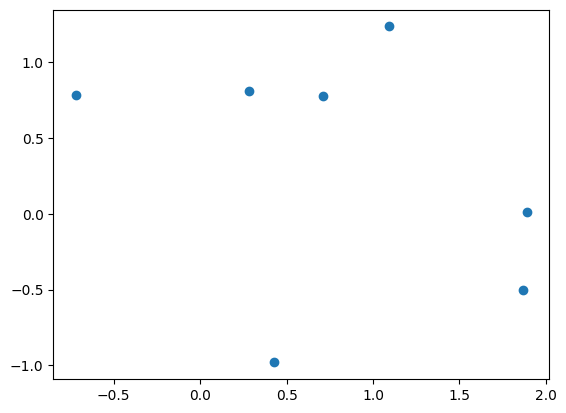

In [490]:
Y = np.array([[ 0.2809285 ,  0.80898861], [ 1.09456245,  1.23648951], [ 1.87013869, -0.499202  ],  [-0.71848399,  0.78346565], [ 0.70826622,  0.7756753 ], [ 1.88928245,  0.01136991],[ 0.42615656, -0.98038825]])
plt.scatter(Y.T[0], Y.T[1])

In [568]:
X 

array([[ 0.29919977],
       [-0.62359688]])

2.6713007060417073e-07


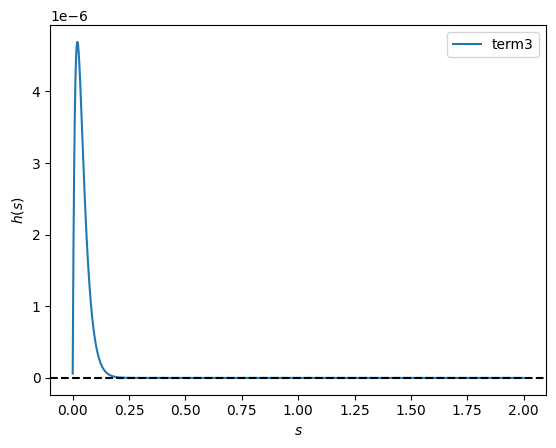

In [944]:
n = 30
d = 2

# X =  np.array([[ 1.7097059 ,  0.77523073],
#        [-0.37119195, -0.94346982],
#        [-0.38705303, -0.29038299],
#        [ 1.15012868, -1.46028591],
#        [-0.70718868,  0.07468164],
#        [-1.00113756,  1.6003973 ],
#        [ 1.41031231, -0.53354534],
#        [ 1.78391861, -0.0042521 ],
#        [ 2.58938972,  0.14468613],
#        [ 0.57619275,  1.39990344],
#        [-0.14114032,  0.5141327 ],
#        [-1.10930753, -1.78088164],
#        [ 0.05042676,  1.26227789],
#        [ 0.92580464, -0.0819123 ],
#        [-1.91783266, -2.18210129],
#        [-1.18119094,  0.81662474],
#        [-0.63480268,  0.46095864],
#        [ 0.47849973,  0.53896307],
#        [-0.86073799,  1.35421093],
#        [-0.28770706, -0.38375298],
#        [-0.50189411, -0.54462339]])

X = np.array([[3.5550, 8.8708],
        [3.0041, 9.1598],
        [6.4373, 7.5973],
        [9.9675, 4.9005],
        [3.5928, 8.8610],
        [0.5855, 9.9373],
        [9.5913, 1.8028],
        [9.5782, 1.8702],
        [3.5267, 8.8794],
        [9.9523, 5.4321]])

# X =  np.random.randn(n, d)  

lam = 1e-3 #1e-6

n_s = 40000
b = 2
s = np.linspace(0.0001, b, num=n_s)

ell = 1.0

out1, separate_terms = compute_integrand2(s, X, ell=ell, lambd=lam, kernel=matern32_kernel)

print(out1.sum() * (b / n_s))
# plt.plot(s, s * separate_terms[0] , label='term1')
# plt.plot(s, separate_terms[1] + separate_terms[2], label = 'term2')
# plt.plot(s, , label = 'term3')
plt.plot(s, out1, label = 'term3')
plt.xlabel('$s$')
plt.ylabel('$h(s)$')
plt.axhline(0, color='k', linestyle='--')
# plt.scatter([1],[0], zorder=2)

plt.legend()


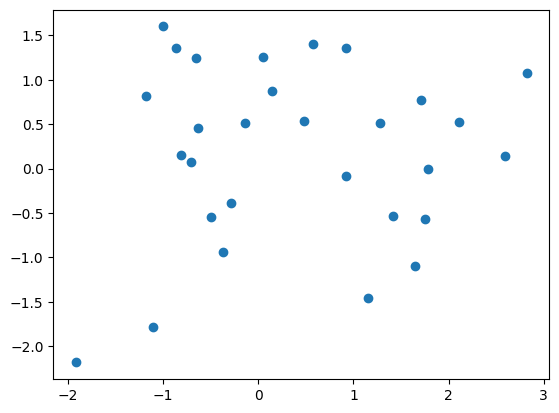

In [775]:
plt.scatter(X.T[0], X.T[1])

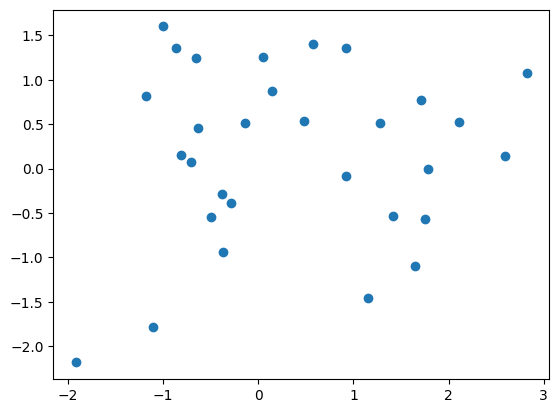

In [753]:
Y = np.array([[ 1.7097059 ,  0.77523073],
       [-0.37119195, -0.94346982],
       [ 0.14462763,  0.87316929],
       [-0.38705303, -0.29038299],
       [ 2.82200025,  1.07865195],
       [ 1.15012868, -1.46028591],
       [-0.70718868,  0.07468164],
       [-1.00113756,  1.6003973 ],
       [ 1.41031231, -0.53354534],
       [ 1.78391861, -0.0042521 ],
       [ 2.58938972,  0.14468613],
       [ 0.57619275,  1.39990344],
       [ 1.27763335,  0.51073207],
       [-0.14114032,  0.5141327 ],
       [-0.81618417,  0.15213372],
       [-1.10930753, -1.78088164],
       [ 0.05042676,  1.26227789],
       [ 0.92580464, -0.0819123 ],
       [ 1.7469897 , -0.56906139],
       [-1.91783266, -2.18210129],
       [-1.18119094,  0.81662474],
       [-0.63480268,  0.46095864],
       [ 1.64628338, -1.10009696],
       [ 0.47849973,  0.53896307],
       [-0.86073799,  1.35421093],
       [-0.28770706, -0.38375298],
       [ 2.11161322,  0.52276674],
       [ 0.92529055,  1.35489293],
       [-0.650474  ,  1.2498211 ],
       [-0.50189411, -0.54462339]])

plt.scatter(Y.T[0], Y.T[1])

In [658]:
X = np.random.randn(n, d)  


[[0.41 ]
 [0.405]]
[[0.41 ]
 [0.406]]
[[0.41 ]
 [0.407]]
[[0.41 ]
 [0.408]]
[[0.41 ]
 [0.409]]
[[0.41]
 [0.41]]
[[0.41 ]
 [0.411]]
[[0.41 ]
 [0.412]]
[[0.41 ]
 [0.413]]
[[0.41 ]
 [0.414]]


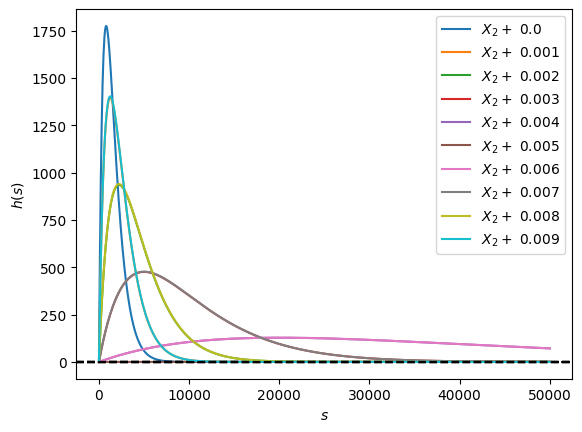

In [602]:
n = 2
d = 1
X = np.array([[0.41], [0.404]])
ell = 0.1
lam = 1e-4#1e-6

n_s = 1000
s = np.linspace(0.0001, 50000, num=n_s)
s_ = s.reshape(n_s, 1)

Xi = X
for i in range(10):
    Xi[1] += 1/1000
    print(Xi)
    out = compute_integrand(s, Xi, ell=ell, lambd=lam)

    plt.plot(s, out, label=f'$X_2 + $ {i/1000}')
    plt.xlabel('$s$')
    plt.ylabel('$h(s)$')
    plt.axhline(0, color='k', linestyle='--')

plt.legend()

In [274]:
np.random.seed(42)

n = 5
d = 2
X = np.random.randn(n, d) 

ell = 1.0
lam = 1e-6

n_s = 100
s = np.linspace(0.01, 10, num=n_s)
s_ = s.reshape(n_s, 1)

compute_integrand(s, X)

array([-3.35395235e-04, -1.99860919e-03, -7.54589735e-04,  3.08640958e-03,
        9.23287290e-03,  1.74151477e-02,  2.73866410e-02,  3.89237399e-02,
        5.18249223e-02,  6.59093893e-02,  8.10154464e-02,  9.69987907e-02,
        1.13730804e-01,  1.31096921e-01,  1.48995101e-01,  1.67334431e-01,
        1.86033871e-01,  2.05021118e-01,  2.24231612e-01,  2.43607650e-01,
        2.63097615e-01,  2.82655294e-01,  3.02239289e-01,  3.21812491e-01,
        3.41341633e-01,  3.60796888e-01,  3.80151524e-01,  3.99381594e-01,
        4.18465666e-01,  4.37384590e-01,  4.56121276e-01,  4.74660515e-01,
        4.92988801e-01,  5.11094187e-01,  5.28966146e-01,  5.46595445e-01,
        5.63974038e-01,  5.81094961e-01,  5.97952242e-01,  6.14540816e-01,
        6.30856444e-01,  6.46895650e-01,  6.62655648e-01,  6.78134286e-01,
        6.93329993e-01,  7.08241724e-01,  7.22868916e-01,  7.37211443e-01,
        7.51269579e-01,  7.65043960e-01,  7.78535550e-01,  7.91745611e-01,
        8.04675671e-01,  

In [ ]:


# Example usage:
# Generate some example data X: n points in d dimensions.
np.random.seed(42)
X = np.random.randn(5, 2)  # 5 points in R^2
n = X.shape[0]
ell = 1.0
lam = 1e-6



# Solve for alpha: (K + lam I) alpha = k0
A = K.copy()
np.fill_diagonal(A, np.diag(A) + lam)
alpha = np.linalg.solve(A, k0)

# Evaluate the full integrand at a set of s values.
s_values = np.linspace(0, 5, 100)
integrand_values = np.array([compute_integrand(s, X, alpha, ell) for s in s_values])

# Print first few values and/or plot
print("s values:", s_values[:5])
print("Integrand values:", integrand_values[:5])

# Plotting (optional)
import matplotlib.pyplot as plt
plt.plot(s_values, integrand_values, label='Integrand')
plt.xlabel('s')
plt.ylabel('Integrand value')
plt.axhline(0, color='k', linestyle='--')
plt.legend()
plt.show()


Matern 3/2 kernel matrix:
 [[0.24256154 0.19649016 0.18181991 0.66153462 0.27484056 0.54842756
  0.42777439 0.66483998]
 [0.14149034 0.14506705 0.23021351 0.41807507 0.31344238 0.19917715
  0.32605109 0.2948297 ]
 [0.22080905 0.1755958  0.11981674 0.47493395 0.26925041 0.13716773
  0.1493225  0.18755335]
 [0.19501405 0.28204309 0.39765955 0.51827996 0.5893213  0.33454287
  0.47151286 0.5057433 ]
 [0.0448768  0.13115571 0.92085727 0.11042028 0.42586208 0.10820415
  0.31387147 0.17957398]
 [0.15495679 0.22744637 0.31652512 0.35208863 0.33404668 0.7048216
  0.60634013 0.89203934]
 [0.08095256 0.08877348 0.13261683 0.1755737  0.11196221 0.65705388
  0.4066567  0.57995308]
 [0.25547102 0.62029883 0.309182   0.39054768 0.92497163 0.20139738
  0.19969345 0.28516842]
 [0.30786705 0.72972846 0.27670866 0.43530928 0.81457376 0.25946768
  0.20852249 0.34564482]
 [0.18952831 0.27375521 0.41063601 0.50922213 0.55014887 0.40249941
  0.55135983 0.60341995]]
IMQ kernel matrix:
 [[0.1041021  0.09232925

# Find worst

In [2]:
import torch

def exp_power_kernel(X, Y, ell, beta=0.01):
    """
    Compute the kernel
        k_ell(x,y) = exp( - (||x-y||/ell)^beta )
    in a vectorized manner.
    
    Parameters:
      X: torch.Tensor of shape [n, d] -- n points in d dimensions.
      Y: torch.Tensor of shape [m, d] -- m points in d dimensions.
      ell: positive scalar, the lengthscale parameter.
      beta: positive scalar exponent.
      
    Returns:
      K: torch.Tensor of shape [n, m] with entries 
         K[i,j] = exp( - (||X[i]-Y[j]||/ell)^beta ).
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Compute the Euclidean distance between points.
    # Add a tiny constant to avoid division by zero.
    r = torch.sqrt(torch.sum(diff**2, dim=2) + 1e-12)
    # Compute the kernel: note that (r/ell)^beta = r^beta / ell^beta.
    K = torch.exp( - (r / ell) ** beta )
    return K

def d_exp_power_kernel_dell(X, Y, ell, beta=0.01):
    """
    Compute the derivative of the kernel
        k_ell(x,y) = exp( - (||x-y||/ell)^beta )
    with respect to the lengthscale ell, i.e.,
    
        ∂_ell k_ell(x,y) = [β/ell^(β+1)] ||x-y||^β k_ell(x,y).
    
    Parameters:
      X: torch.Tensor of shape [n, d]
      Y: torch.Tensor of shape [m, d]
      ell: positive scalar, the lengthscale parameter.
      beta: positive scalar exponent.
      
    Returns:
      dK: torch.Tensor of shape [n, m] containing the derivative of the kernel 
          with respect to ell.
    """
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    r = torch.sqrt(torch.sum(diff**2, dim=2) + 1e-12)
    K = torch.exp( - (r / ell) ** beta )
    dK = (beta * r**beta / (ell**(beta + 1))) * K
    return dK


In [3]:
import torch

def matern12(X, Y, ell, sigma):
    """
    Compute the Matern 1/2 (exponential) kernel between each row of X and Y.
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar)
      sigma: amplitude (scalar)
      
    Returns:
      K: Tensor of shape [n, m] containing the covariance between points in X and Y.
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Compute Euclidean distance (with a small term added for numerical stability)
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    # Exponential kernel (Matern 1/2)
    K = sigma**2 * torch.exp(-r / ell)
    return K

def d_matern12_dell(X, Y, ell, sigma):
    """
    Compute the derivative of the Matern 1/2 (exponential) kernel with respect to the lengthscale ell.
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar)
      sigma: amplitude (scalar)
      
    Returns:
      dK: Tensor of shape [n, m] containing the derivative of the covariance with respect to ell.
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Compute Euclidean distances
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    # Derivative with respect to ell:
    # d/dell exp(-r/ell) = exp(-r/ell) * (r / ell^2)
    dK = sigma**2 * torch.exp(-r / ell) * (r / (ell**2))
    return dK


In [4]:
import torch

def periodic_kernel(X, Y, ell, sigma, p=1.):
    """
    Compute the periodic kernel between each row of X and Y.
    
    The kernel is defined as:
    
      k_ell(x, y) = sigma^2 * exp( - (2/p^2) * sin^2( pi * ||x-y|| / ell ) )
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar) controlling the scaling of the difference between x and y.
      sigma: amplitude (scalar)
      p: period parameter (scalar) controlling the periodic structure
      
    Returns:
      K: Tensor of shape [n, m] containing the covariance between points in X and Y.
    """
    # Compute pairwise differences: shape [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Euclidean distance (with a tiny constant added for numerical stability)
    r = torch.sum(diff**2, dim=2)
    # Compute the sine squared term: sin^2( pi*r / ell )
    A = torch.sin(torch.pi * r / ell) ** 2
    # Compute the kernel
    K = sigma**2 * torch.exp(-2 * A / (p**2))
    return K

def d_periodic_kernel_dell(X, Y, ell, sigma, p=1.):
    """
    Compute the derivative of the periodic kernel with respect to the lengthscale ell.
    
    For the kernel:
    
      k_ell(x,y) = sigma^2 * exp( - (2/p^2) * sin^2( pi * ||x-y|| / ell ) )
    
    we have (using the chain rule):
    
      d/dell k_ell(x,y) = k_ell(x,y) * (2πr/(p^2 ell^2)) * sin(2πr/ell)
    
    where r = ||x-y||.
    
    Parameters:
      X: Tensor of shape [n, d]
      Y: Tensor of shape [m, d]
      ell: lengthscale (scalar)
      sigma: amplitude (scalar)
      p: period parameter (scalar)
      
    Returns:
      dK: Tensor of shape [n, m] containing the derivative of k_ell with respect to ell.
    """
    # Compute pairwise differences and Euclidean distance.
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    r = torch.sqrt(torch.sum(diff**2, dim=2) + 1e-12)
    
    # Compute the sine squared term used in the kernel.
    A = torch.sin(torch.pi * r / ell) ** 2
    # Compute the kernel.
    K = sigma**2 * torch.exp(-2 * A / (p**2))
    
    # Compute derivative of sin^2(pi*r/ell) with respect to ell.
    # Let v = pi*r/ell, so that sin^2(v)' = 2 sin(v) cos(v) * (-pi*r/ell^2)
    # That is, d/dell sin^2(pi*r/ell) = - (pi*r/ell^2) sin(2pi*r/ell).
    #
    # Then by the chain rule:
    #   d/dell k_ell(x,y) = k_ell(x,y) * (-2/p^2) * (d/dell sin^2(pi*r/ell))
    #                     = k_ell(x,y) * (-2/p^2) * ( - (pi*r/ell^2)* sin(2pi*r/ell) )
    #                     = k_ell(x,y) * (2*pi*r/(p^2 * ell^2)) * sin(2pi*r/ell).
    
    dK = K * (2 * torch.pi * r * torch.sin(2 * torch.pi * r / ell)) / (p**2 * ell**2)
    return dK


In [5]:
import torch

def kernel_exp(X, Y, ell, sigma):
    """
    Compute the kernel 
      k_ell(x,y) = exp(exp(-||x-y||^2/ell^2) - 1)
    between each row of X and Y, using the squared Euclidean distance.
    
    Args:
        X: torch.Tensor of shape [n, d]
        Y: torch.Tensor of shape [m, d]
        ell: scalar (or a 0-d torch.Tensor) representing the lengthscale
        sigma: scalar, the overall scale parameter
    
    Returns:
        K: torch.Tensor of shape [n, m]
    """
    # Compute pairwise differences.
    # X: [n, d], Y: [m, d] -> diff: [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    
    # Compute squared Euclidean distances: r2 = ||x-y||^2.
    r2 = torch.sum(diff ** 2, dim=2)
    
    # Compute k_ell(x,y) = exp(exp(-r2/ell^2) - 1)
    K = torch.exp(torch.exp(-r2 / ell**2) - 1)
    return sigma ** 2 * K

def d_kernel_exp_dell(X, Y, ell, sigma):
    """
    Compute the derivative of the kernel 
      k_ell(x,y) = exp(exp(-||x-y||^2/ell^2) - 1)
    with respect to the lengthscale ell.
    
    The derivative is given by:
      d/dell k_ell(x,y) = 2 * k_ell(x,y) * (r2/ell^3) * exp(-r2/ell^2),
    where r2 = ||x-y||^2.
    
    Args:
        X: torch.Tensor of shape [n, d]
        Y: torch.Tensor of shape [m, d]
        ell: scalar (or a 0-d torch.Tensor) representing the lengthscale
        sigma: scalar, the overall scale parameter
    
    Returns:
        dK: torch.Tensor of shape [n, m]
    """
    # Compute pairwise differences.
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    
    # Compute squared Euclidean distances.
    r2 = torch.sum(diff ** 2, dim=2)
    
    # Compute the kernel.
    K = torch.exp(torch.exp(-r2 / ell**2) - 1)
    
    # Compute the derivative: dK = 2*K*(r2/ell^3)*exp(-r2/ell^2)
    dK = 2 * K * (r2 / (ell ** 3)) * torch.exp(-r2 / ell**2)
    return sigma ** 2 * dK


In [6]:
import torch

def matern32(X, Y, ell, sigma):
    """
    Compute the Matern 3/2 kernel between each row of X and Y.
    X: tensor of shape [n, d]
    Y: tensor of shape [m, d]
    ell: lengthscale (scalar)
    sigma: amplitude (scalar)
    Returns:
      K: tensor of shape [n, m]
    """
    # Compute pairwise differences and Euclidean distances
    # X: [n,d], Y: [m,d] --> diff: [n, m, d]
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    # Add a small number for numerical stability
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    sqrt3 = torch.sqrt(torch.tensor(3.0, device=X.device))
    z = sqrt3 * r / ell
    K = sigma**2 * (1.0 + z) * torch.exp(-z)
    return K

def d_matern32_dell(X, Y, ell, sigma):
    """
    Compute the derivative of the Matern 3/2 kernel with respect to ell.
    X: tensor of shape [n, d]
    Y: tensor of shape [m, d]
    Returns:
      dK: tensor of shape [n, m]
    """
    diff = X.unsqueeze(1) - Y.unsqueeze(0)
    r = torch.sqrt(torch.sum(diff ** 2, dim=2) + 1e-12)
    sqrt3 = torch.sqrt(torch.tensor(3.0, device=X.device))
    z = sqrt3 * r / ell
    dK = sigma**2 * ( (sqrt3 * r / ell)**2 / ell ) * torch.exp(-z)
    # which is equivalent to sigma^2 * (3 * r^2)/(ell^3) * exp(-z)
    return dK

def g_prime(X, ell, sigma, lambd, kernel=matern12, dkernel=d_matern12_dell):
    """
    Compute the derivative g'(ell) with respect to the kernel hyperparameter ell.
    X: tensor of shape [n, d]
    ell: lengthscale (scalar)
    sigma: amplitude (scalar)
    lambd: regularization parameter (scalar)
    
    Returns:
      gp: scalar (the value of g'(ell))
    """
    n = X.shape[0]
    device = X.device
    # Define 0 in R^d
    zero = torch.zeros(1, X.shape[1], device=device)
    
    # Compute k(0, X) and its derivative: shape [1, n]
    k0 = kernel(zero, X, ell, sigma)         # [1, n]
    dk0 = dkernel(zero, X, ell, sigma)   # [1, n]
    
    # Compute K = k(X,X) and its derivative: shape [n, n]
    K = kernel(X, X, ell, sigma)
    dK = dkernel(X, X, ell, sigma)
    
    # Regularize the kernel matrix
    K_reg = K + lambd * torch.eye(n, device=device)
    
    # Solve for alpha:  K_reg * alpha = k0^T
    alpha = torch.linalg.solve(K_reg, k0.t())  # shape [n, 1]
    
    # Compute g'(ell) = 2*(dk0 @ alpha) - alpha^T @ dK @ alpha.
    term1 = 2 * (dk0 @ alpha)       # shape [1, 1]
    term2 = (alpha.t() @ dK @ alpha)  # shape [1, 1]
    gp = term1 - term2
    return gp.squeeze()  # return a scalar


In [7]:
def repulsion_penalty(X, gamma=1.0):
    """
    Compute a repulsion penalty to discourage points from being too close.
    
    Parameters:
      X: Tensor of shape [n, d]
      gamma: controls the width of the repulsion (scalar)
      
    Returns:
      repulsion: a scalar tensor that is large if many pairs of points are very close.
    """
    # Compute pairwise differences: shape [n, n, d]
    diff = X.unsqueeze(1) - X.unsqueeze(0)
    # Compute squared Euclidean distances: shape [n, n]
    sq_dist = torch.sum(diff ** 2, dim=2)
    
    # Create an upper-triangular mask to avoid double-counting and ignore self-distances.
    n = X.shape[0]
    mask = torch.triu(torch.ones(n, n, device=X.device), diagonal=1)
    
    # Compute the repulsion penalty:
    # For pairs (i,j), if they are too close (small sq_dist), exp(-sq_dist/(2*gamma^2)) is near 1.
    repulsion = torch.sum(torch.exp(-sq_dist / (2 * gamma**2)) * mask)
    
    return repulsion

def target_distance_penalty(X, r_target, reg_coef_target=1.0):
    """
    Compute a penalty to encourage the average distance from the origin to be near r_target.
    
    Parameters:
      X: Tensor of shape [n, d]
      r_target: desired average distance from the origin (scalar)
      reg_coef_target: regularization coefficient for this penalty
      
    Returns:
      penalty: scalar tensor
    """
    # Compute the Euclidean norm of each point.
    distances = torch.norm(X, dim=1)
    avg_distance = torch.mean(distances)
    penalty = reg_coef_target * (avg_distance - r_target)**2
    return penalty


Text(0.5, 1.0, 'Using $\\ell = 0.01$')

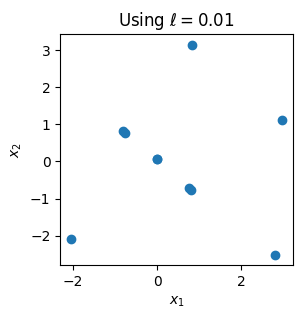

In [1239]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (3,3)

x_detach = optimal_X.detach()

plt.scatter(x_detach.T[0], x_detach.T[1], zorder=2, alpha=1)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Using $\ell = 0.01$')
# plt.scatter(X.T[0], X.T[1], alpha=1, zorder=1, color='green', marker='x')

# for i in range(x_detach.shape[0]):
#     plt.plot([X[i][0], x_detach[i][0]], [X[i][1], x_detach[i][1]], zorder=0, color='red')

In [8]:
X = torch.randn(10,2) * 0.1

ell = 0.001
sigma = 1.
lambd = 1

optimal_X = optimize_X(X, ell, sigma, lambd,
               reg_coef_target=1e-7, reg_coef_repulsion=1e-7, gamma=1.,
               lr=1e-3, n_iters=20000,
               kernel=kernel_exp, dkernel=d_kernel_exp_dell)



NameError: name 'optimize_X' is not defined

In [ ]:
ells = torch.linspace(1e-4, 1e-2, 100)

g_prime(x_detach, )

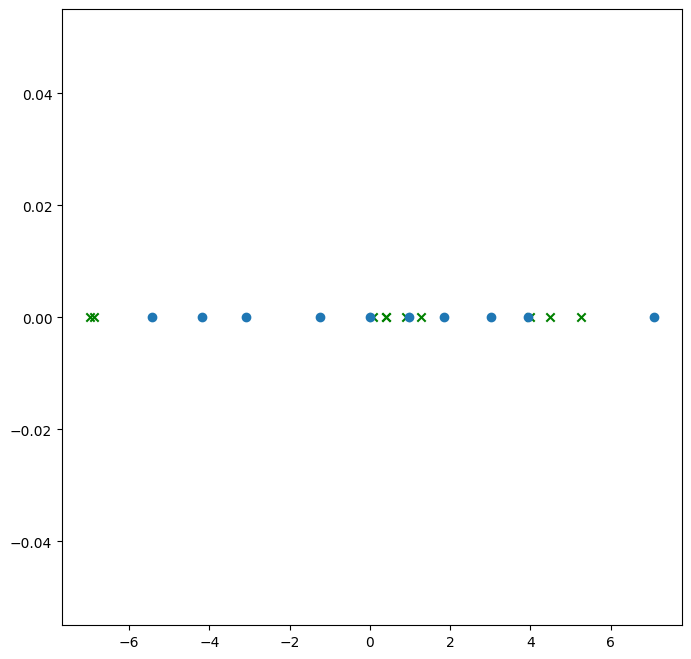

In [1175]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8,8)

x_detach = optimal_X.detach()

plt.scatter(x_detach.T[0], torch.zeros_like(x_detach.T[0]), zorder=2, alpha=1)
plt.scatter(X.T[0], torch.zeros_like(x_detach.T[0]), zorder=1, color='green', marker='x')

# plt.scatter(X.T[0], X.T[1], alpha=1, zorder=1, color='green', marker='x')

# for i in range(x_detach.shape[0]):
#     plt.plot([X[i][0], x_detach[i][0]], [X[i][1], x_detach[i][1]], zorder=0, color='red')

In [1178]:
X = torch.randn(50,2) * 5

ell = 0.5
sigma = 1.
lambd = 1e-4

optimal_X = optimize_X(X, ell, sigma, lambd,
               reg_coef_target=1e-5, reg_coef_repulsion=1e-2, gamma=1.,
               lr=1e-3, n_iters=20000,
               kernel=exp_power_kernel, dkernel=d_exp_power_kernel_dell)



Iter 0: loss = 0.4077, gp = 0.1970, target_penalty = 0.0003, repulsion = 0.2105
Iter 100: loss = 0.3239, gp = 0.1387, target_penalty = 0.0003, repulsion = 0.1850
Iter 200: loss = 0.2638, gp = 0.1003, target_penalty = 0.0003, repulsion = 0.1633
Iter 300: loss = 0.2191, gp = 0.0750, target_penalty = 0.0003, repulsion = 0.1438
Iter 400: loss = 0.1860, gp = 0.0580, target_penalty = 0.0003, repulsion = 0.1277
Iter 500: loss = 0.1617, gp = 0.0462, target_penalty = 0.0003, repulsion = 0.1153
Iter 600: loss = 0.1433, gp = 0.0377, target_penalty = 0.0003, repulsion = 0.1053
Iter 700: loss = 0.1287, gp = 0.0315, target_penalty = 0.0003, repulsion = 0.0969
Iter 800: loss = 0.1169, gp = 0.0269, target_penalty = 0.0003, repulsion = 0.0898
Iter 900: loss = 0.1072, gp = 0.0232, target_penalty = 0.0003, repulsion = 0.0836
Iter 1000: loss = 0.0990, gp = 0.0204, target_penalty = 0.0003, repulsion = 0.0783
Iter 1100: loss = 0.0919, gp = 0.0181, target_penalty = 0.0003, repulsion = 0.0735
Iter 1200: loss 

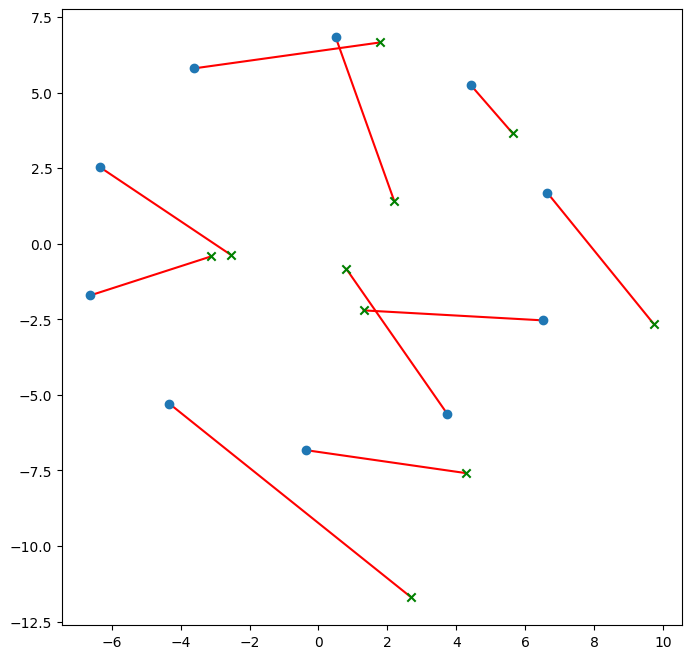

In [1184]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8,8)

x_detach = optimal_X.detach()

plt.scatter(x_detach.T[0], x_detach.T[1], zorder=2, alpha=1)
plt.scatter(X.T[0], X.T[1], alpha=1, zorder=1, color='green', marker='x')

for i in range(x_detach.shape[0]):
    plt.plot([X[i][0], x_detach[i][0]], [X[i][1], x_detach[i][1]], zorder=0, color='red')

5.992374598161492e-06


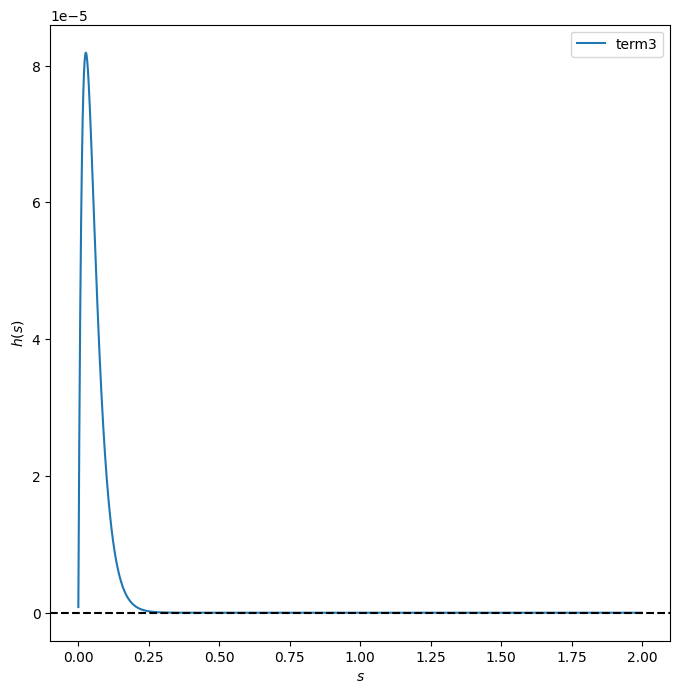

In [1131]:

Y = x_detach.numpy()

out1, separate_terms = compute_integrand2(s, Y, ell=ell, lambd=lambd, kernel=matern32_kernel)

print(out1.sum() * (b / n_s))
# plt.plot(s, s * separate_terms[0] , label='term1')
# plt.plot(s, separate_terms[1] + separate_terms[2], label = 'term2')
# plt.plot(s, , label = 'term3')
plt.plot(s, out1, label = 'term3')
plt.xlabel('$s$')
plt.ylabel('$h(s)$')
plt.axhline(0, color='k', linestyle='--')
# plt.scatter([1],[0], zorder=2)

plt.legend()

In [1113]:
g_prime(x_detach/100, ell, 1., 1e-9)

tensor(0.4552)

In [ ]:
g_prime(x_detach, 1., 1., 1e-9)

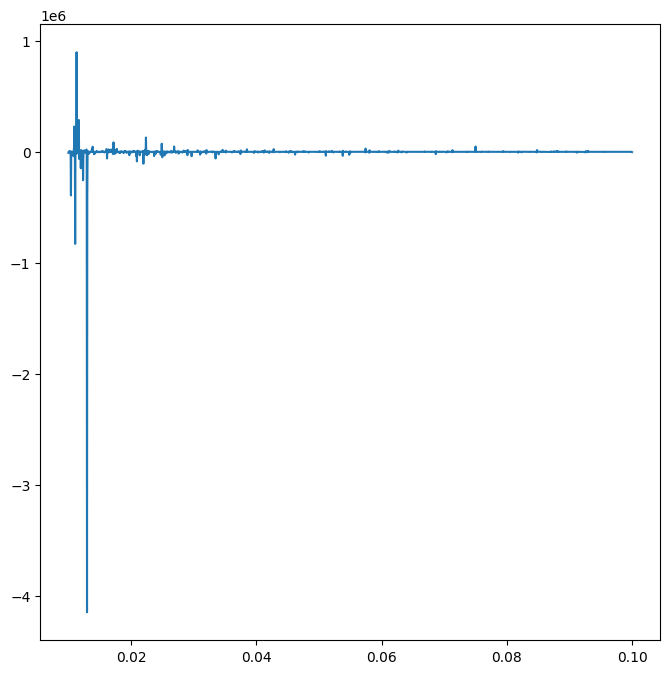

In [1168]:
ells = torch.linspace(0.01, 0.1, 2000)

gs2 = []

for i in ells:
    gs2.append(g_prime(x_detach, i, 1., 1e-4, kernel=periodic_kernel, dkernel=d_periodic_kernel_dell))


plt.plot(ells,torch.stack(gs2))

In [1139]:
torch.stack(gs2)

tensor([0.0000e+00, 4.3152e-11, 3.2318e-05, 2.1032e-03, 1.3194e-02, 3.3302e-02,
        5.4432e-02, 7.0509e-02, 7.9942e-02, 8.3697e-02, 8.3445e-02, 8.0694e-02,
        7.6555e-02, 7.1770e-02, 6.6799e-02, 6.1914e-02, 5.7264e-02, 5.2923e-02,
        4.8918e-02, 4.5251e-02, 4.1908e-02, 3.8868e-02, 3.6105e-02, 3.3596e-02,
        3.1314e-02, 2.9239e-02, 2.7348e-02, 2.5623e-02, 2.4047e-02, 2.2604e-02,
        2.1282e-02, 2.0066e-02, 1.8948e-02, 1.7917e-02, 1.6965e-02, 1.6085e-02,
        1.5269e-02, 1.4513e-02, 1.3809e-02, 1.3154e-02, 1.2544e-02, 1.1974e-02,
        1.1442e-02, 1.0943e-02, 1.0476e-02, 1.0037e-02, 9.6253e-03, 9.2377e-03,
        8.8728e-03, 8.5287e-03, 8.2040e-03, 7.8973e-03, 7.6072e-03, 7.3326e-03,
        7.0725e-03, 6.8257e-03, 6.5916e-03, 6.3691e-03, 6.1577e-03, 5.9564e-03,
        5.7648e-03, 5.5822e-03, 5.4081e-03, 5.2419e-03, 5.0833e-03, 4.9316e-03,
        4.7866e-03, 4.6478e-03, 4.5150e-03, 4.3877e-03, 4.2657e-03, 4.1487e-03,
        4.0364e-03, 3.9285e-03, 3.8249e-